In [1]:
# Principal Component Analysis (PCA)

In [2]:
# Step 1: Import Required Libraries

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Step 2: Creating Sample Dataset

data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
    # 1 = Male, 0 = Female
}

df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [4]:
# Step 3: Standardizing the Data

X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("Standardized Data:")
print(X_scaled)

Standardized Data:
[[ 0.18419807  0.13867505  0.50910379  1.        ]
 [-0.52425605 -0.69337525 -0.59764358 -1.        ]
 [ 1.60110632  1.52542554  1.61585117  1.        ]
 [ 0.8926522   0.5547002   0.06640484  1.        ]
 [-1.23271018 -1.24807544 -1.26169201 -1.        ]
 [ 0.46757972  0.83205029  0.95180275  1.        ]
 [-0.09918358 -0.2773501  -0.15494463 -1.        ]
 [ 1.17603385  1.38675049  1.17315222  1.        ]
 [-0.94932853 -0.83205029 -0.81899306 -1.        ]
 [-1.51609183 -1.38675049 -1.48304149 -1.        ]]


In [5]:
# Step 4: Applying PCA Algorithm

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Transformed Data:")
print(X_pca)


# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42
)

PCA Transformed Data:
[[ 0.90005784  0.63516169]
 [-1.3998906  -0.38005711]
 [ 2.88165429 -0.44045863]
 [ 1.24720863  0.46035914]
 [-2.37553282  0.15965573]
 [ 1.62063399  0.25901251]
 [-0.7496539  -0.73608984]
 [ 2.37324514 -0.1473138 ]
 [-1.79678422 -0.15360555]
 [-2.70093834  0.34333585]]


In [6]:
# Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

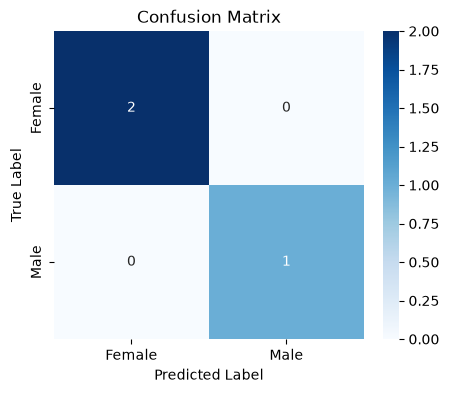

In [7]:
# Step 5: Evaluating with Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Female', 'Male'],
    yticklabels=['Female', 'Male']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

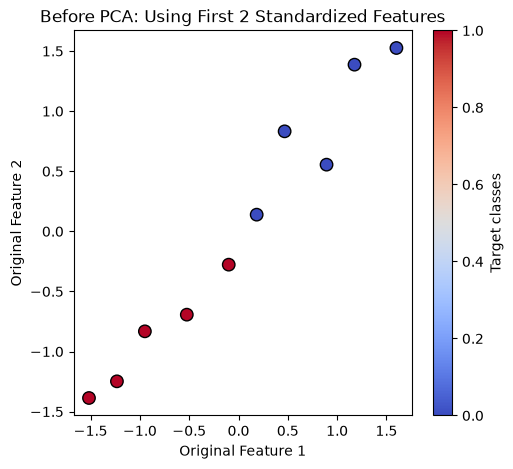

In [8]:
# Step 6: Visualizing PCA Result

y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))


# Before PCA

plt.subplot(1, 2, 1)

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

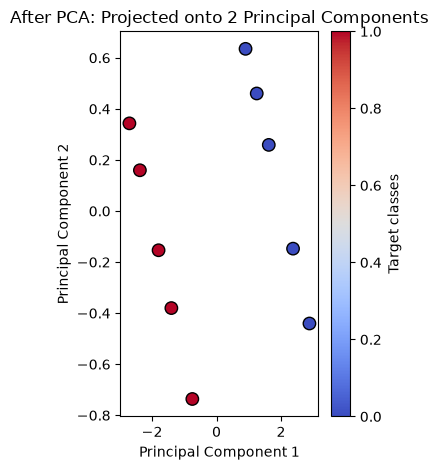

In [9]:
# After PCA

plt.subplot(1, 2, 2)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

In [10]:
#Extra Part

Explained Variance Ratio:
[0.94041611 0.04378473]

Total Variance Retained:
0.9842008396200406


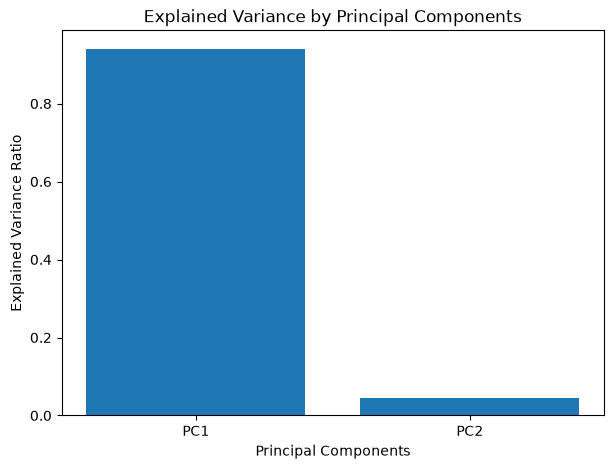

In [11]:
# Extra 1: Explained Variance Ratio

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Retained:")
print(sum(pca.explained_variance_ratio_))


# Visualizing Explained Variance

plt.figure(figsize=(7, 5))

plt.bar(
    ['PC1', 'PC2'],
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")

plt.show()

Cumulative Explained Variance:
[0.94041611 0.98420084 0.99736775 1.        ]


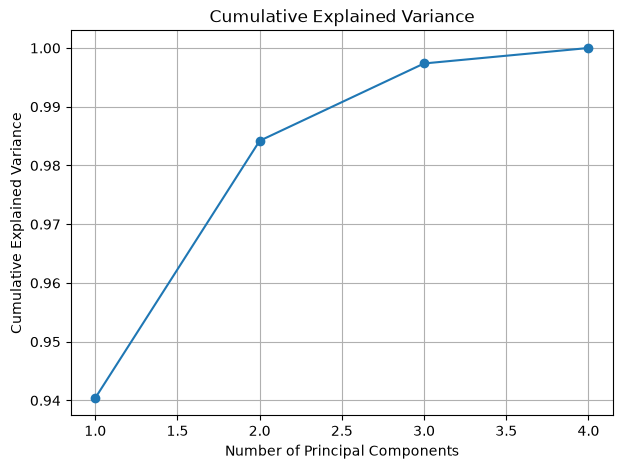

In [13]:
# Cumulative Explained Variance

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Cumulative Explained Variance:")
print(cumulative_variance)

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid(True)
plt.show()

In [17]:
#Dimension Reduction Comparison

print("Original Number of Features:", X.shape[1])
print("Number of Features After PCA:", X_pca.shape[1])

print("\nOriginal Shape:")
print(X.shape)

print("\nPCA Transformed Shape:")
print(X_pca.shape)

Original Number of Features: 3
Number of Features After PCA: 2

Original Shape:
(10, 3)

PCA Transformed Shape:
(10, 2)


In [18]:
#  Creating DataFrame from PCA Components

pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

pca_df['Gender'] = y.values

print("PCA Dataset:")
print(pca_df)

PCA Dataset:
   Principal Component 1  Principal Component 2  Gender
0               0.900058               0.635162       1
1              -1.399891              -0.380057       0
2               2.881654              -0.440459       1
3               1.247209               0.460359       1
4              -2.375533               0.159656       0
5               1.620634               0.259013       1
6              -0.749654              -0.736090       0
7               2.373245              -0.147314       1
8              -1.796784              -0.153606       0
9              -2.700938               0.343336       0


In [19]:
# Comparing Dimensions

print("Original Data Shape:", X.shape)
print("PCA Data Shape:", X_pca.shape)

Original Data Shape: (10, 3)
PCA Data Shape: (10, 2)


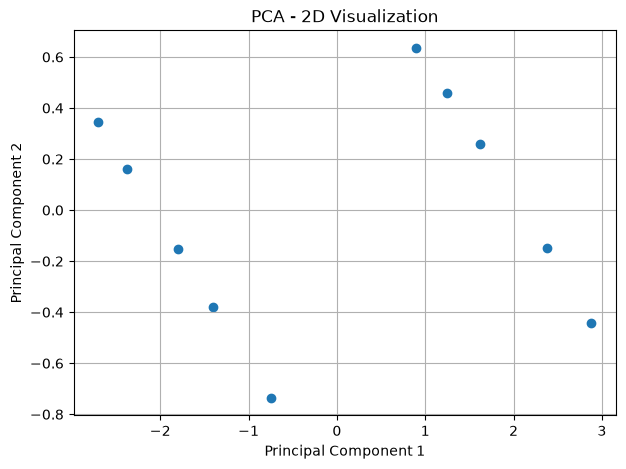

In [20]:
# Visualizing PCA Dataset

plt.figure(figsize=(7, 5))

plt.scatter(
    pca_df['Principal Component 1'],
    pca_df['Principal Component 2']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization")

plt.grid(True)
plt.show()

In [21]:
# Principal Component Statistics

print("Mean of Principal Components:")
print(pca_df[['Principal Component 1', 'Principal Component 2']].mean())

print("\nStandard Deviation of Principal Components:")
print(pca_df[['Principal Component 1', 'Principal Component 2']].std())

Mean of Principal Components:
Principal Component 1   -4.440892e-17
Principal Component 2   -4.996004e-17
dtype: float64

Standard Deviation of Principal Components:
Principal Component 1    2.044414
Principal Component 2    0.441134
dtype: float64


In [22]:
# Correlation Between Principal Components

correlation = pca_df[
    ['Principal Component 1', 'Principal Component 2']
].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                       Principal Component 1  Principal Component 2
Principal Component 1                    1.0                    0.0
Principal Component 2                    0.0                    1.0


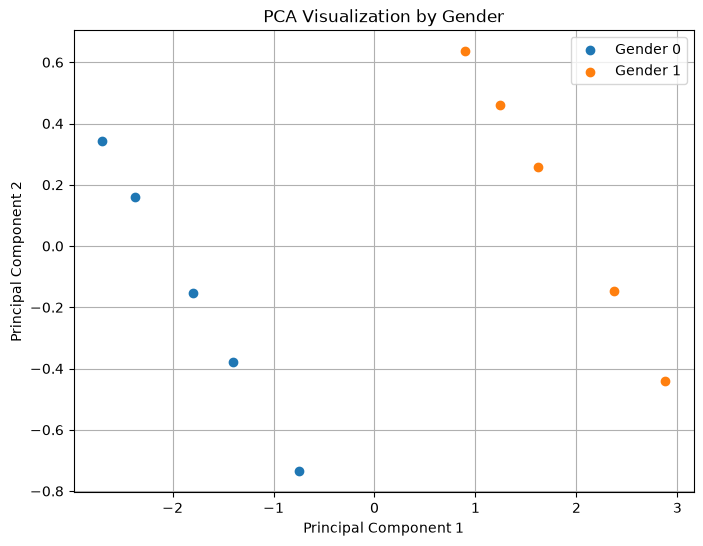

In [23]:
# PCA Visualization with Gender

plt.figure(figsize=(8, 6))

for gender in sorted(pca_df['Gender'].unique()):
    subset = pca_df[pca_df['Gender'] == gender]

    plt.scatter(
        subset['Principal Component 1'],
        subset['Principal Component 2'],
        label=f'Gender {gender}'
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization by Gender")
plt.legend()
plt.grid(True)
plt.show()